In [11]:

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [12]:

load_dotenv()

True

In [13]:

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.7
)

In [14]:
loader = PyPDFLoader("my_paper.pdf")
docs = loader.load()

In [15]:
docs

[Document(metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2021-09-14T02:52:38+00:00', 'author': '', 'keywords': '', 'moddate': '2021-09-14T02:52:38+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) kpathsea version 6.3.2', 'subject': '', 'title': '', 'trapped': '/False', 'rgid': 'PB:357213035_AS:1103436619751424@1640091199662', 'source': 'my_paper.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='See discussions, stats, and author profiles for this publication at: https://www.researchgate.net/publication/357213035\nDevelopment of Multiple Combined Regression Methods for Rainfall\nMeasurement Development of Multiple Combined Regression Methods for\nRainfall Measurement\nArticle · December 2021\nCITATIONS\n0\nREADS\n711\n6 authors, including:\nNusrat Jahan Prottasha\nDaffodil International University\n26 PUBLICATIONS\xa0\xa0\xa0299 CITATIONS\xa0\xa0\xa0\nSEE PROFILE\nMd Kowsher\nSteven

In [16]:
len(docs)

15

In [17]:
splitter=RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks=splitter.split_documents(docs)

In [18]:
len(chunks)

44

In [19]:
embeddings=GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)

In [20]:
vector_store=FAISS.from_documents(chunks,embeddings)
vector_store.save_local("my_vector_store")

In [21]:
retriever=vector_store.as_retriever(search_type="similarity",search_kwargs={"k": 3})

In [22]:
ans=retriever.invoke("What is the main topic of this paper?")
ans

[Document(id='e8025f44-c7fc-4de1-96b5-153a3d5fdbb3', metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2021-09-14T02:52:38+00:00', 'author': '', 'keywords': '', 'moddate': '2021-09-14T02:52:38+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) kpathsea version 6.3.2', 'subject': '', 'title': '', 'trapped': '/False', 'rgid': 'PB:357213035_AS:1103436619751424@1640091199662', 'source': 'my_paper.pdf', 'total_pages': 15, 'page': 4, 'page_label': '5'}, page_content='Rainfall Prediction 3\n– We have discussed a big comparison among all trained models to ﬁgure out\nthe best performer.\nThe paper is organized as takes after: Section II clariﬁes the related work of\ndiﬀerent classiﬁcation strategies for the forecast of rain classiﬁcation. Section-III\ndepicts the technique and materials utilized. Section-IV depicts the experimental\nanalysis including performance and result. Section V talks about the conclusion\nof

In [24]:
@tool
def rag_tool(query: str) -> str:
    """
    Retrieve relevant information from the PDF document.
    Use this tool when the user asks factual or conceptual questions
    that may be answered using the stored PDF documents.
    Args:
        query: The question or search query used to retrieve PDF content.
    """
    documents = retriever.invoke(query)
    if not documents:
        return "No relevant information was found in the PDF."
    formatted_documents = []
    for index, document in enumerate(documents, start=1):
        source = document.metadata.get("source", "Unknown source")
        page = document.metadata.get("page", "Unknown page")
        formatted_documents.append(
            f"Document {index}\n"
            f"Source: {source}\n"
            f"Page: {page}\n"
            f"Content: {document.page_content}"
        )
    return "\n\n".join(formatted_documents)

In [25]:
tools=[rag_tool]
llm_with_tools=llm.bind_tools(tools)

In [26]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [27]:
def chat_node(state:ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node=ToolNode(tools)


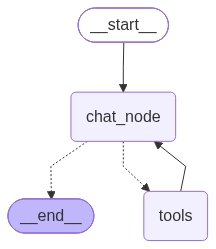

In [28]:
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")  
chatbot = graph.compile()

chatbot

In [29]:
result=chatbot.invoke({"messages":[HumanMessage(content='Hello')]})

print(result['messages'][-1].content)

e:\Chatbot-Langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPq8P9iBzkL8Pzcdkpkh2lH3NYArR502MrfOfH2by01Ij7LtM7U60YGsuVdQ2VVae/Eag+zDveM6vFHbG1CC9RuKYmB9UkMnakXnrRf1kkFDjsDZB+Kwpz'}}]


In [30]:
result = chatbot.invoke({"messages": [HumanMessage(content="Using the pdf notes, explain about Rainfall Measurement techniques in a concise way")]})
print(result["messages"][-1].content)

e:\Chatbot-Langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
e:\Chatbot-Langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
e:\Chatbot-Langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Based on the provided PDF notes, rainfall measurement and forecasting rely on two main approaches:\n\n1. **Conventional Equipment:** Traditional methods use various physical equipment to foresee rainfall by monitoring climate conditions such as temperature, humidity, and atmospheric pressure. However, these conventional strategies often lack productivity and precision.\n2. **Machine Learning and Predictive Regression Analysis:** To overcome the limitations of traditional equipment, modern techniques use historical weather data (spanning over 10 years) and supervised machine learning regressors. Steps in this data-driven approach typically include:\n   * **Data Collection & Pre-processing:** Gathering data, cleaning, handling missing values and outliers, exploratory data analysis (EDA), feature selection, and feature scaling.\n   * **Model Training:** Applying multiple combined regression analysis techniques (supervised machine learning models) to accurately q

In [31]:
print(result['messages'][-1].content[0]['text'])

Based on the provided PDF notes, rainfall measurement and forecasting rely on two main approaches:

1. **Conventional Equipment:** Traditional methods use various physical equipment to foresee rainfall by monitoring climate conditions such as temperature, humidity, and atmospheric pressure. However, these conventional strategies often lack productivity and precision.
2. **Machine Learning and Predictive Regression Analysis:** To overcome the limitations of traditional equipment, modern techniques use historical weather data (spanning over 10 years) and supervised machine learning regressors. Steps in this data-driven approach typically include:
   * **Data Collection & Pre-processing:** Gathering data, cleaning, handling missing values and outliers, exploratory data analysis (EDA), feature selection, and feature scaling.
   * **Model Training:** Applying multiple combined regression analysis techniques (supervised machine learning models) to accurately quantify the exact amount of rain